In [85]:
import pandas as pd

In [86]:
df = pd.read_csv('./data/ObesityDataSet_raw_and_data_sinthetic.csv')
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [87]:
#On veut prédire la colonne NObeyesdad
df.NObeyesdad.value_counts()

# c'est une un problème de classification multi-classes avec 7 classes différentes avec une ordinalité potentielle (Insufficient → Normal → Overweight I/II → Obesity I/II/III)

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [88]:
len(df)

2111

In [89]:
print(df.MTRANS.value_counts()) # 5 catégories - Which transportation do you usually use?
print(df.Gender.value_counts()) # passer en 0/1
print(df.Age.value_counts())
print(df.Height.value_counts())
print(df.Weight.value_counts())
print(df.family_history_with_overweight.value_counts()) # passer en 0/1 # Has a family member suffered or suffers from overweight?
print(df.FAVC.value_counts()) #  passer en 0/1 - Do you eat high caloric food frequently?
print(df.FCVC.value_counts()) # Do you usually eat vegetables in your meals?
print(df.NCP.value_counts()) # How many main meals do you have daily?
print(df.CAEC.value_counts()) # 4 catégories - Do you eat any food between meals?
print(df.SMOKE.value_counts()) # passer en 0/1 # sous représentation des fumeurs
print(df.SCC.value_counts()) # passer en 0/1 # 	Do you monitor the calories you eat daily?
print(df.FAF.value_counts()) # How often do you have physical activity?
print(df.TUE.value_counts()) # How much time do you use technological devices such as cell phone, videogames, television, computer and others?
print(df.CH2O.value_counts()) # How much water do you drink daily? 
print(df.CALC.value_counts()) # 4 catégories


MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64
Gender
Male      1068
Female    1043
Name: count, dtype: int64
Age
18.000000    128
26.000000    101
21.000000     96
23.000000     89
19.000000     59
            ... 
21.680123      1
24.469756      1
25.127910      1
25.986368      1
23.761970      1
Name: count, Length: 1402, dtype: int64
Height
1.700000    60
1.650000    50
1.600000    43
1.750000    39
1.620000    36
            ..
1.643421     1
1.640535     1
1.626483     1
1.645990     1
1.631547     1
Name: count, Length: 1574, dtype: int64
Weight
80.000000     59
70.000000     43
50.000000     42
75.000000     40
60.000000     37
              ..
111.939983     1
111.555967     1
111.357062     1
111.922491     1
102.174953     1
Name: count, Length: 1525, dtype: int64
family_history_with_overweight
yes    1726
no      385
Name: count, dtype: in

In [90]:
print(df.isna().sum())

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


In [91]:
print(df.dtypes)


Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object


In [92]:
%pip install scikit-learn
%pip install lightgbm
%pip install matplotlib
%pip install seaborn
%pip install mord

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, matthews_corrcoef, confusion_matrix, make_scorer, classification_report
from sklearn.model_selection import StratifiedKFold, cross_validate
import lightgbm as lgb
import warnings
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr
from sklearn.model_selection import GridSearchCV


In [ ]:
# On ajoute le BMI qui est une relation non linéaire pour améliorer le modèle
def add_basic_features(df):
    if {'Weight', 'Height'}.issubset(df.columns):
        df['BMI'] = df['Weight'] / (df['Height']**2)
    return df

df = add_basic_features(df)

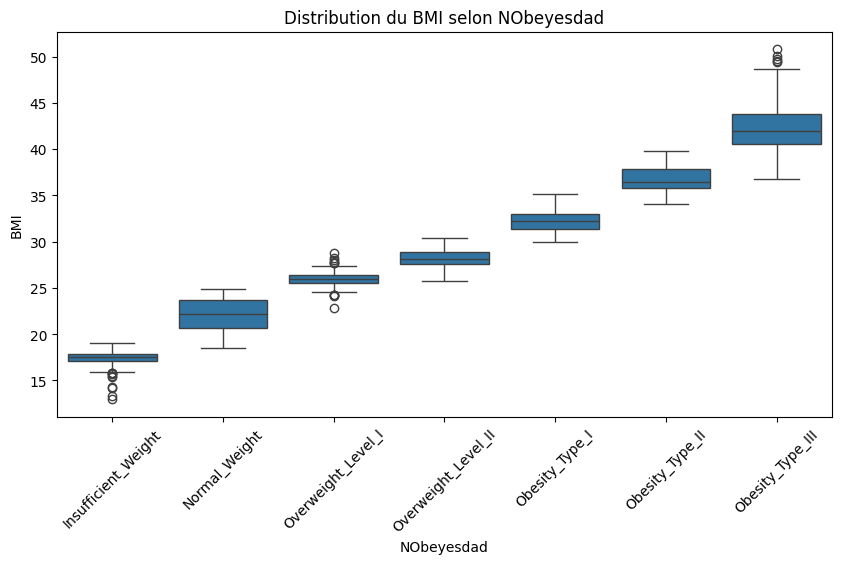

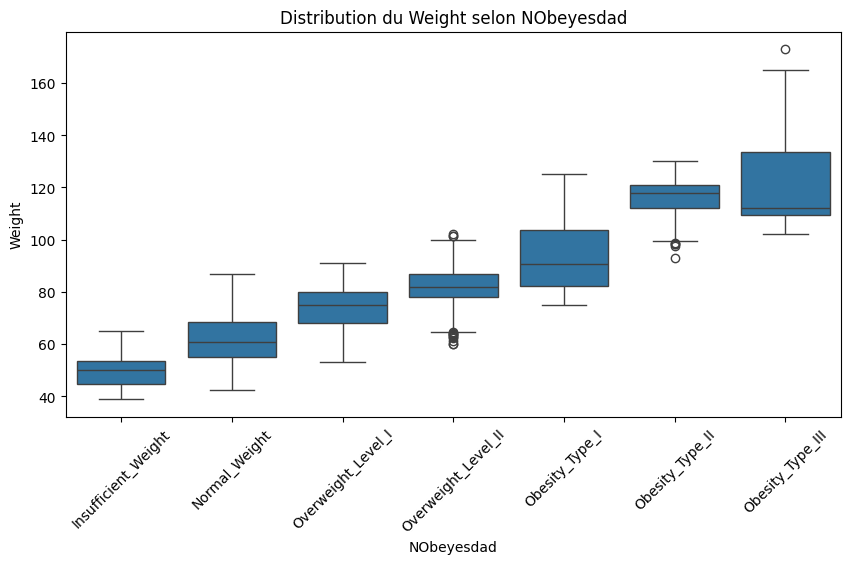

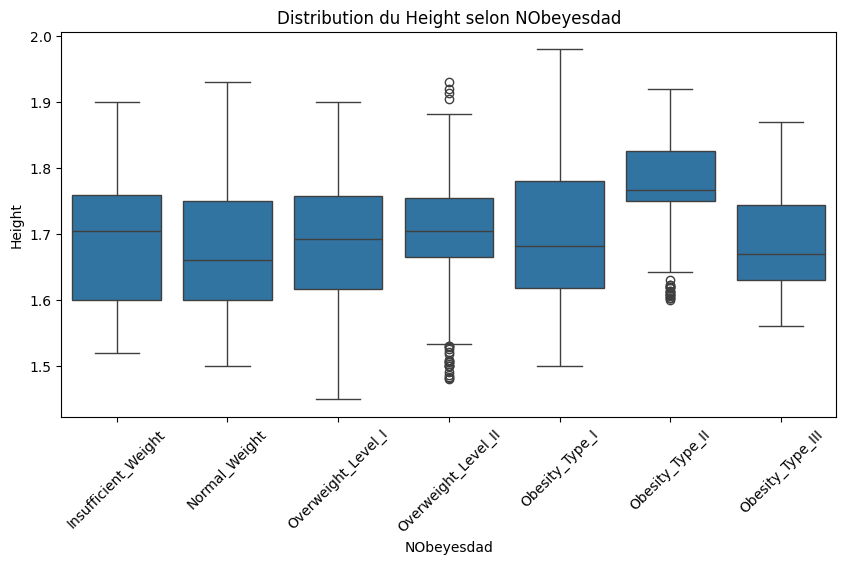

Corrélation de Spearman entre BMI et NObeyesdad_ord : 0.988 (p=0.00e+00)


In [ ]:
ordinal_mapping = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}
df['NObeyesdad_ord'] = df['NObeyesdad'].map(ordinal_mapping)

# Boxplot BMI vs NObeyesdad
plt.figure(figsize=(10,5))
sns.boxplot(x='NObeyesdad', y='BMI', data=df, order=ordinal_mapping.keys())
plt.title('Distribution du BMI selon NObeyesdad')
plt.xticks(rotation=45)
plt.show()

# Boxplot Weight vs NObeyesdad
plt.figure(figsize=(10,5))
sns.boxplot(x='NObeyesdad', y='Weight', data=df, order=ordinal_mapping.keys())
plt.title('Distribution du Weight selon NObeyesdad')
plt.xticks(rotation=45)
plt.show()

# Boxplot Height vs NObeyesdad
plt.figure(figsize=(10,5))
sns.boxplot(x='NObeyesdad', y='Height', data=df, order=ordinal_mapping.keys())
plt.title('Distribution du Height selon NObeyesdad')
plt.xticks(rotation=45)
plt.show()

# Corrélation BMI <-> NObeyesdad_ord
corr_bmi, pval_bmi = spearmanr(df['BMI'], df['NObeyesdad_ord'])
print(f"Corrélation de Spearman entre BMI et NObeyesdad_ord : {corr_bmi:.3f} (p={pval_bmi:.2e})")


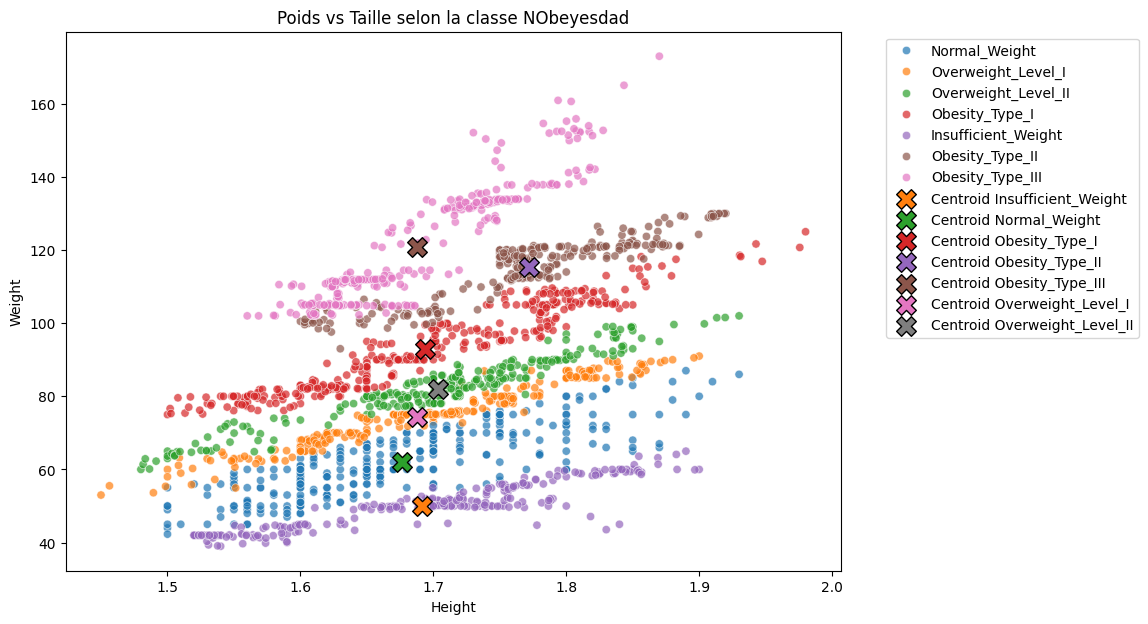

In [96]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='Height', y='Weight', hue='NObeyesdad', data=df, palette='tab10', alpha=0.7)
# Affichage des centroïdes par classe
centroids = df.groupby('NObeyesdad')[['Height','Weight']].mean()
for idx, row in centroids.iterrows():
    plt.scatter(row['Height'], row['Weight'], marker='X', s=200, label=f'Centroid {idx}', edgecolor='black')
plt.title('Poids vs Taille selon la classe NObeyesdad')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [97]:
df = df.drop(columns=["Weight", "Height", "BMI", "NObeyesdad_ord"], errors='ignore')

#en effet ces weight et height sont directement lié avec la target d'obésité
X = df.drop(columns=['NObeyesdad'])
y = df['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist() #respecte bien ce qui a été observé avec les values_counts()

In [99]:
preproc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=10), cat_cols)
    ],
    remainder='drop'
)

In [ ]:
# Modèle ordinal avec mord
from mord import LogisticIT
from sklearn.pipeline import Pipeline

# Encodage ordinal de la target
ordinal_mapping = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}
y_train_ord = y_train.map(ordinal_mapping)
y_test_ord = y_test.map(ordinal_mapping)

pipe_mord = Pipeline([
    ('preproc', preproc),
    ('clf', LogisticIT())
])

pipe_mord.fit(X_train, y_train_ord)
y_pred_ord = pipe_mord.predict(X_test)

# MAE ordinale
mae_ord = (y_test_ord - y_pred_ord).abs().mean()
print('MAE ordinale (mord) sur le test set:', mae_ord)

# Matrice de confusion ordinale
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_ord, y_pred_ord)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion (mord)')
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.show()

In [105]:
# Affichage des coefficients du modèle LogisticIT (mord)
import pandas as pd
coefs = pipe_mord.named_steps['clf'].coef_
feature_names = preproc.get_feature_names_out()
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
print('Coefficients estimés (LogisticIT) :')
display(coef_df.sort_values('coef', key=abs, ascending=False))

Coefficients estimés (LogisticIT) :


,feature,coef
13,cat__CAEC_Frequently,-0.844091
24,cat__MTRANS_Automobile,-0.482441
9,cat__family_history_with_overweight_yes,0.480040
8,cat__family_history_with_overweight_no,-0.479587
14,cat__CAEC_Sometimes,0.354964
15,cat__CAEC_no,0.354940
22,cat__CALC_no,-0.331085
23,cat__CALC_infrequent_sklearn,0.301594
25,cat__MTRANS_Public_Transportation,0.270355
0,num__Age,0.270076


In [ ]:
# Vérification de l'overfitting pour mord
y_pred_train_ord = pipe_mord.predict(X_train)
mae_train = (y_train_ord - y_pred_train_ord).abs().mean()
print('MAE ordinale (mord) sur le train set:', mae_train)
print('MAE ordinale (mord) sur le test set:', mae_ord)

In [ ]:
# GridSearchCV avec MAE ordinale comme score

# Définition du scorer MAE ordinale
def mae_ordinale(y_true, y_pred):
    ordinal_mapping = {
        'Insufficient_Weight': 0,
        'Normal_Weight': 1,
        'Overweight_Level_I': 2,
        'Overweight_Level_II': 3,
        'Obesity_Type_I': 4,
        'Obesity_Type_II': 5,
        'Obesity_Type_III': 6
    }
    y_true_ord = pd.Series(y_true).map(ordinal_mapping)
    y_pred_ord = pd.Series(y_pred).map(ordinal_mapping)
    return (y_true_ord - y_pred_ord).abs().mean()

mae_scorer = make_scorer(mae_ordinale, greater_is_better=False)

# Exemple avec RandomForest (adapter pour d'autres modèles si besoin)
param_grid = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [4, 8, 12],
    'clf__min_samples_split': [2, 5, 10]
}

pipe_rf = Pipeline([
    ('preproc', preproc),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

grid = GridSearchCV(pipe_rf, param_grid, scoring=mae_scorer, cv=3, n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

print('Meilleurs hyperparamètres (MAE ordinale):', grid.best_params_)
print('Meilleur score MAE ordinale:', -grid.best_score_)

# Prédictions et évaluation sur le test set
y_pred = grid.predict(X_test)
mae_test = mae_ordinale(y_test, y_pred)
print('MAE ordinale sur le test set:', mae_test)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Meilleurs hyperparamètres (MAE ordinale): {'clf__max_depth': 12, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Meilleur score MAE ordinale: 2.2996899779107163
MAE ordinale sur le test set: 2.0526315789473686


In [102]:
# GridSearchCV avec MAE ordinale pour LightGBM
from lightgbm import LGBMClassifier

param_grid_lgb = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [4, 8, 12],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__num_leaves': [15, 31, 63]
}

pipe_lgb = Pipeline([
    ('preproc', preproc),
    ('clf', LGBMClassifier(
        objective='multiclass',
        num_class=7,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

grid_lgb = GridSearchCV(pipe_lgb, param_grid_lgb, scoring=mae_scorer, cv=3, n_jobs=-1, verbose=2)
grid_lgb.fit(X_train, y_train)

print('Meilleurs hyperparamètres LightGBM (MAE ordinale):', grid_lgb.best_params_)
print('Meilleur score MAE ordinale LightGBM:', -grid_lgb.best_score_)

# Prédictions et évaluation sur le test set
y_pred_lgb = grid_lgb.predict(X_test)
mae_test_lgb = mae_ordinale(y_test, y_pred_lgb)
print('MAE ordinale LightGBM sur le test set:', mae_test_lgb)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Meilleurs hyperparamètres LightGBM (MAE ordinale): {'clf__learning_rate': 0.1, 'clf__max_depth': 8, 'clf__n_estimators': 200, 'clf__num_leaves': 63}
Meilleur score MAE ordinale LightGBM: 2.2374186758515116
MAE ordinale LightGBM sur le test set: 2.0210526315789474


In [110]:
%pip install tensorflow

  Using cached tensorflow-2.20.0-cp310-cp310-win_amd64.whl.metadata (4.6 kB)
Using cached tensorflow-2.20.0-cp310-cp310-win_amd64.whl (331.7 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'c:\\Users\\CHAUVEAUDEQUERCIZEEl\\OneDrive - ENGIE\\Bureau\\Cours ENSAE\\Applied Statistics\\.venv\\Lib\\site-packages\\tensorflow\\include\\external\\com_github_grpc_grpc\\src\\core\\lib\\security\\credentials\\gcp_service_account_identity\\gcp_service_account_identity_credentials.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths



In [ ]:
# Réseau de neurones pour classification ordinale (méthode CORAL)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.base import BaseEstimator, TransformerMixin

# Encodage ordinal de la target en format CORAL (K > 2 classes => K-1 sorties binaires)
def coral_encode(y, n_classes):
    # y: array of class indices (0 ... n_classes-1)
    # returns: (n_samples, n_classes-1) binary matrix
    y = np.asarray(y)
    return np.greater_equal.outer(y, np.arange(1, n_classes)).astype('float32')

n_classes = 7

y_train_ord = y_train.map(ordinal_mapping)
y_test_ord = y_test.map(ordinal_mapping)
Y_train_coral = coral_encode(y_train_ord, n_classes)
Y_test_coral = coral_encode(y_test_ord, n_classes)

# Utilisation du même préprocessing déjà entraîné
X_train_prep = preproc.transform(X_train)
X_test_prep = preproc.transform(X_test)

# Construction du modèle Keras
inputs = keras.Input(shape=(X_train_prep.shape[1],))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(n_classes-1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=[]
)

# Entraînement
history = model.fit(
    X_train_prep, Y_train_coral,
    validation_data=(X_test_prep, Y_test_coral),
    epochs=30,
    batch_size=32,
    verbose=2
)

# Prédiction : conversion des sorties CORAL en classes
proba = model.predict(X_test_prep)
# Pour chaque échantillon, la classe prédite est le nombre de sorties > 0.5
pred_ord = (proba > 0.5).sum(axis=1)

# MAE ordinale
mae_nn = np.abs(pred_ord - y_test_ord.values).mean()
print('MAE ordinale (réseau de neurones CORAL) sur le test set:', mae_nn)

# Matrice de confusion
from sklearn.metrics import confusion_matrix
cm_nn = confusion_matrix(y_test_ord, pred_ord)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion (NN CORAL)')
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.show()

ModuleNotFoundError: No module named 'tensorflow.python'